### Exercícios Práticos – Métodos de Interpolação Polinomial

Considere a tabela com os valores abaixo para utilizar os códigos desenvolvidos em sala de aula, com **N = 100 pontos** no intervalo dos dados.

Apresente o **plot das curvas** dos polinômios interpoladores utilizando:
- Método de **Lagrange**
- Método de **Newton**
- **Splines Cúbicas**


| x     | 0  | 6  | 10 | 13 | 17 | 20 | 28 |
|-------|----|----|----|----|----|----|----|
| f(x)  | 6  | 17 | 42 | 37 | 30 | 29 | 28 |

In [8]:
import numpy as np
import matplotlib.pyplot as plt

xi = np.array([0, 6, 10, 13, 17, 20, 28])
yi = np.array([6, 17, 42, 37, 30, 29, 28])

def plot(x, y):
    plt.plot(x, y, "b-")
    plt.plot(xi, yi, "mo")
    plt.grid()
    plt.show()

### Método de Lagrange

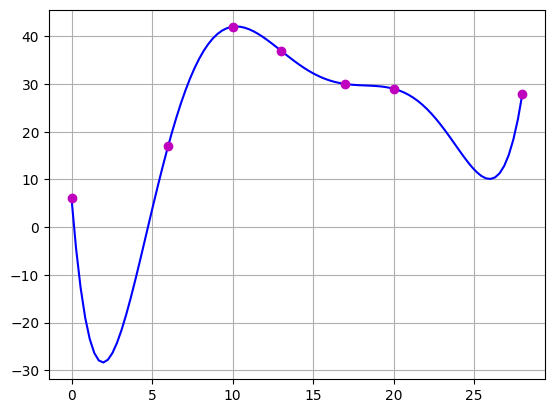

In [9]:
def lagrange(xi, yi):
    n = len(xi)
    n_pontos = 100 #numero de pontos da malha
    x = np.linspace(xi[0], xi[n - 1], n_pontos)

    L = np.ones((n, n_pontos))

    for i in range(n):
        for j in range(n):
            if i != j:
                L[i, :] *= ((x - xi[j]) / (xi[i] - xi[j]))

    y = yi @ L
    return x, y

x, y = lagrange(xi, yi)
plot(x, y)

## Método de Newton

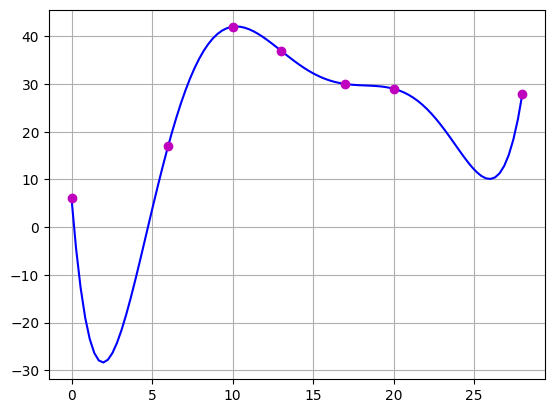

In [10]:
def newton(xi, yi):
    n = len(xi)
    n_pontos = 100
    x = np.linspace(xi[0], xi[n - 1], n_pontos)

    D = np.zeros((n, n))

    D[:, 0] = yi
    for j in range(1, n):
        for i in range(j, n):
            D[i, j] = (D[i, j - 1] - D[i - 1, j - 1]) / (xi[i] - xi[i - j])

    c = np.diag(D)
    y = np.ones(n_pontos) * c[0]
    xv = np.ones(n_pontos)

    for j in range(1, n):
        xv *= (x - xi[j - 1])
        y += c[j] * xv

    return x, y

x, y = newton(xi, yi)
plot(x, y)

### Método Splines

C:\Users\Vinícius Mardegan\AppData\Local\Temp\ipykernel_20936\1678536138.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[k] = a[idx] + b[idx] * t + c[idx] * t ** 2 + d[idx] * t ** 3


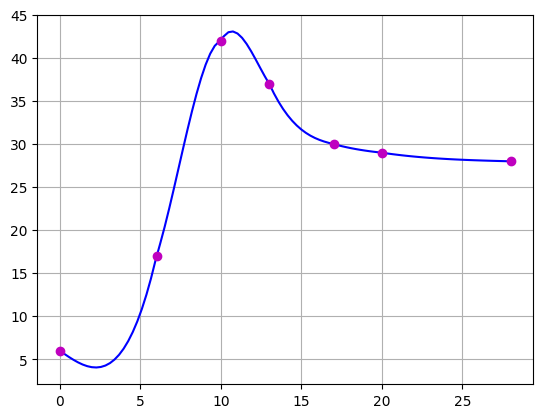

In [11]:
def splines(xi, yi):
    n = len(xi)
    n_pontos = 100 #numero de pontos da malha
    x = np.linspace(xi[0], xi[n - 1], n_pontos)

    m = n - 1 #subintervalos
    h = np.zeros(n - 1)

    for i in range(n - 1):
        h[i] = xi[i + 1] - xi[i]

    a = yi
    A = np.zeros((n, n))
    r = np.zeros((n, 1))

    A[0, 0] = A[n - 1, n - 1] = 1

    for j in range(1, n - 1):
        A[j, j - 1] = h[j - 1]
        A[j, j] = 2 * h[j - 1] + h[j]
        A[j, j + 1] = h[j]
        r[j] = 3 * ((a[j + 1] - a[j]) / h[j] - (a[j] - a[j - 1]) / h[j - 1])

    c = np.linalg.solve(A, r)

    d = np.zeros((m, 1))
    b = np.zeros((m, 1))

    for j in range(m):
        d[j] = (c[j + 1] - c[j]) / (3 * h[j])
        b[j] = (a[j + 1] - a[j]) / h[j] - h[j] / 3 * (2 * c[j] + c[j + 1])

    y = np.zeros(n_pontos)

    for k in range(n_pontos):
        idx = m
        for j in range(m):
            if x[k] <= xi[j + 1]:
                idx = j
                break
        t = x[k] - xi[idx]
        y[k] = a[idx] + b[idx] * t + c[idx] * t ** 2 + d[idx] * t ** 3

    return x, y

x, y = splines(xi, yi)
plot(x, y)